# Using a deformable mirror

Fiatlux separates the physical deformable mirror from its control basis.

A `ControlBasis` maps a command vector onto an OPD map.

Here we use a Zernike basis and observe its effect on the PSF.

In [1]:
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from fiatlux.core.grid import Grid
from fiatlux.core.spectrum import Band, Spectrum
from fiatlux.core.source import PlaneWave
from fiatlux.optics.elements.mask import CircularAperture
from fiatlux.optics.elements.deformable_mirror import (
    ActuatorGrid,
    DeformableMirror,
    ZernikeBasis,
)
from fiatlux.optics.propagator import MFTPropagator
from fiatlux.system.optical_system import SerialSystem

In [2]:
D = 1.0
wavelength = 1.65e-6
focal_length = 10.0

N_pupil = 256
N_focal = 256

pupil_grid = Grid(
    nx=N_pupil,
    ny=N_pupil,
    dx=D / N_pupil,
    dy=D / N_pupil,
)

focal_grid = Grid(
    nx=N_focal,
    ny=N_focal,
    dx=focal_length * wavelength / D / 4,
    dy=focal_length * wavelength / D / 4,
)

band = Band(
    central_wavelength=wavelength,
    delta_wavelength=0.0,
    f0=368.0,
)

spectrum = Spectrum(magnitude=0, band=band, samples=1)
source = PlaneWave(spectrum=spectrum)

aperture = CircularAperture(grid=pupil_grid, radius=D / 2)

propagator = MFTPropagator(
    focal_length=focal_length,
    output_grid=focal_grid,
)

## Build the DM and its modal control basis

In [3]:
n_modes = 15

basis = ZernikeBasis(
    pixel_grid=pupil_grid,
    n=n_modes,
)

actuator_grid = ActuatorGrid(
    n_actuators_x=1,
    n_actuators_y=1,
    pitch=D,
)

dm = DeformableMirror(
    grid=pupil_grid,
    actuator_grid=actuator_grid,
    pixel_grid=pupil_grid,
    control_basis=basis,
    stroke=500e-9,
)

print(dm.commands)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


/Users/janinpop/Documents/code/fiatlux/.venv/lib/python3.14/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4384.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


## Excite one mode

Each command is expressed relative to the DM stroke.

In [4]:
commands = torch.zeros(n_modes)

mode_index = 3
commands[mode_index] = 0.2

dm.commands = commands

## Display the DM OPD map

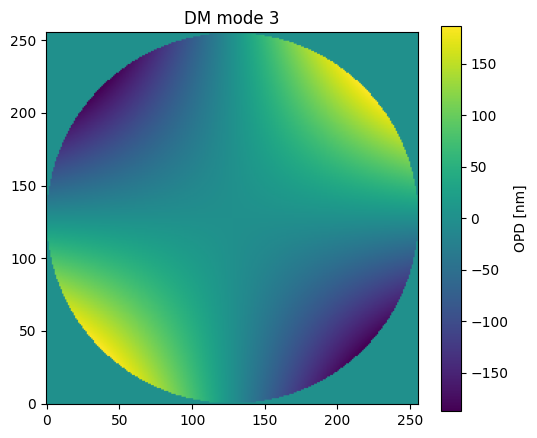

In [5]:
plt.figure(figsize=(6, 5))

plt.imshow(
    (dm.opd * 1e9).cpu(),
    origin="lower",
)

plt.title(f"DM mode {mode_index}")
plt.colorbar(label="OPD [nm]")
plt.show()

## Propagate through the DM

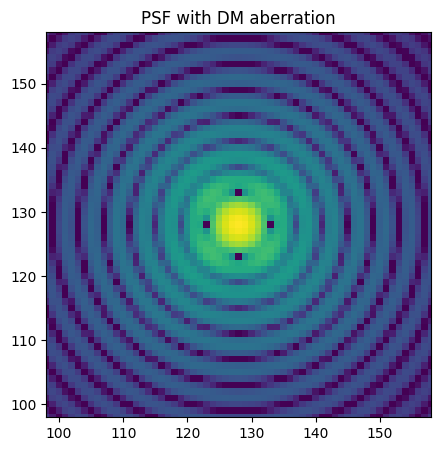

In [6]:
dm_system = SerialSystem(
    elements=[
        aperture,
        dm,
        propagator,
    ]
)

dm_result = dm_system.run(source)

dm_psf = dm_result.field_at(propagator).intensity().sum(0)
dm_psf = dm_psf / dm_psf.max()

plt.figure(figsize=(6, 5))
plt.imshow(
    dm_psf.cpu(),
    origin="lower",
    norm=LogNorm(vmin=1e-5, vmax=1),
)

plt.xlim(N_focal // 2 - 30, N_focal // 2 + 30)
plt.ylim(N_focal // 2 - 30, N_focal // 2 + 30)

plt.title("PSF with DM aberration")
plt.show()